In [ ]:
# Cell 1 — Imports and connection
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine 
from urllib.parse import quote_plus
from sqlalchemy.engine import URL   ## URL.create() already handles special-character encoding internally, no need to wrap password with quote_plus() anymore.
import os
from dotenv import load_dotenv

sns.set_style('whitegrid')

load_dotenv(dotenv_path='../.env')

url = URL.create(
    drivername='postgresql+psycopg2',
    username=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
    host=os.getenv('DB_HOST'),
    port=int(os.getenv('DB_PORT')),
    database=os.getenv('DB_NAME')
)

engine = create_engine(url)

In [4]:
# Cell 2 — Pull total cost by category and year (Query 1)
query1 = """
SELECT claim_type, claim_year, SUM(clm_pmt_amt) AS total_cost, COUNT(*) AS claim_count
FROM claims_with_beneficiary
GROUP BY claim_type, claim_year
ORDER BY claim_type, claim_year;
"""
cost_by_category = pd.read_sql(query1, engine)
cost_by_category

,claim_type,claim_year,total_cost,claim_count
0,Inpatient,2007.0,2770000.0,224
1,Inpatient,2008.0,257732880.0,27678
2,Inpatient,2009.0,244810270.0,25231
3,Inpatient,2010.0,132669330.0,13572
4,Inpatient,NaN,1277700.0,68
5,Outpatient,2007.0,265120.0,312
6,Outpatient,2008.0,73141190.0,282896
7,Outpatient,2009.0,87972330.0,322358
8,Outpatient,2010.0,47913710.0,173971
9,Outpatient,NaN,15232360.0,11253


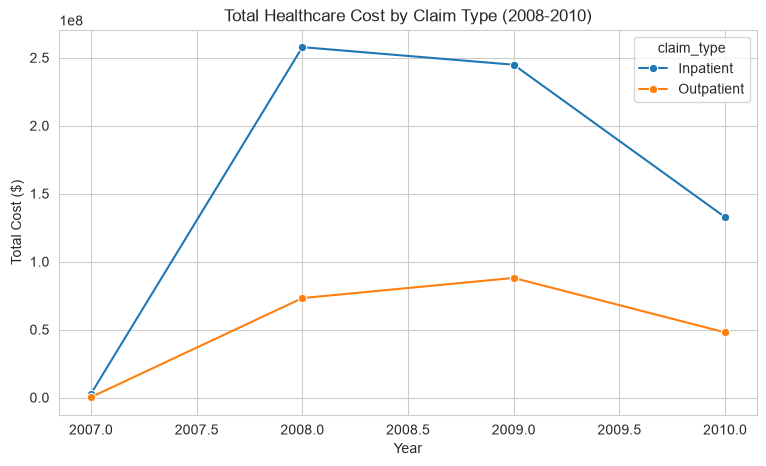

In [5]:
# Cell 3 — Trend line: total cost over time by claim type
plt.figure(figsize=(9,5))
sns.lineplot(data=cost_by_category, x='claim_year', y='total_cost', hue='claim_type', marker='o')
plt.title('Total Healthcare Cost by Claim Type (2008-2010)')
plt.ylabel('Total Cost ($)')
plt.xlabel('Year')
plt.show()

In [6]:
# Cell 4 — YoY growth (Query 2)
query2 = """
WITH yearly_cost AS (
    SELECT claim_type, claim_year, SUM(clm_pmt_amt) AS total_cost
    FROM claims_with_beneficiary GROUP BY claim_type, claim_year
)
SELECT claim_type, claim_year, total_cost,
    LAG(total_cost) OVER (PARTITION BY claim_type ORDER BY claim_year) AS prior_year_cost,
    ROUND(100.0 * (total_cost - LAG(total_cost) OVER (PARTITION BY claim_type ORDER BY claim_year))
        / NULLIF(LAG(total_cost) OVER (PARTITION BY claim_type ORDER BY claim_year), 0), 2) AS yoy_growth_pct
FROM yearly_cost ORDER BY claim_type, claim_year;
"""
yoy_growth = pd.read_sql(query2, engine)
yoy_growth

,claim_type,claim_year,total_cost,prior_year_cost,yoy_growth_pct
0,Inpatient,2007.0,2770000.0,NaN,NaN
1,Inpatient,2008.0,257732880.0,2770000.0,9204.44
2,Inpatient,2009.0,244810270.0,257732880.0,-5.01
3,Inpatient,2010.0,132669330.0,244810270.0,-45.81
4,Inpatient,NaN,1277700.0,132669330.0,-99.04
5,Outpatient,2007.0,265120.0,NaN,NaN
6,Outpatient,2008.0,73141190.0,265120.0,27487.96
7,Outpatient,2009.0,87972330.0,73141190.0,20.28
8,Outpatient,2010.0,47913710.0,87972330.0,-45.54
9,Outpatient,NaN,15232360.0,47913710.0,-68.21


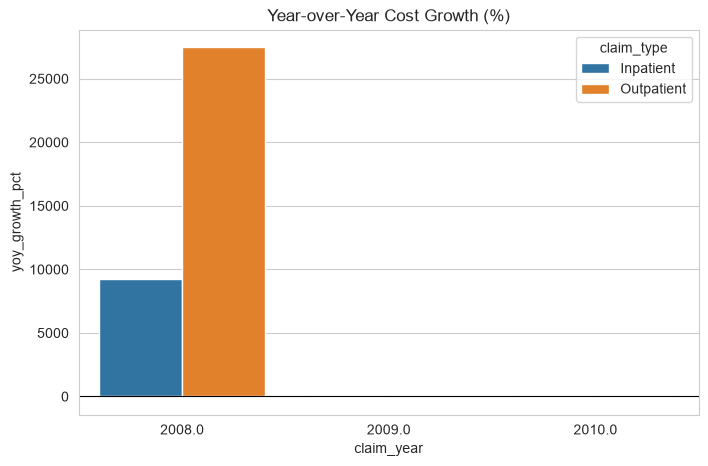

In [7]:
# Cell 5 — Bar chart: YoY growth %
plt.figure(figsize=(8,5))
sns.barplot(data=yoy_growth.dropna(), x='claim_year', y='yoy_growth_pct', hue='claim_type')
plt.title('Year-over-Year Cost Growth (%)')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

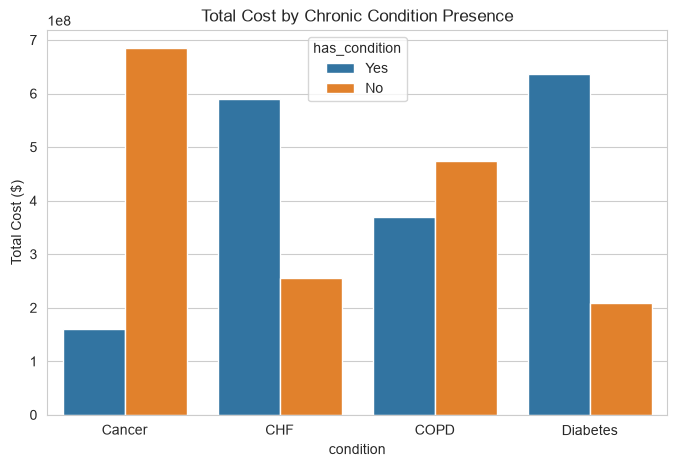

In [8]:
# Cell 6 — Cost by chronic condition (Query 3b)
query3 = """
SELECT 'CHF' AS condition, sp_chf AS flag, SUM(clm_pmt_amt) AS total_cost FROM claims_with_beneficiary GROUP BY sp_chf
UNION ALL
SELECT 'Diabetes', sp_diabetes, SUM(clm_pmt_amt) FROM claims_with_beneficiary GROUP BY sp_diabetes
UNION ALL
SELECT 'Cancer', sp_cncr, SUM(clm_pmt_amt) FROM claims_with_beneficiary GROUP BY sp_cncr
UNION ALL
SELECT 'COPD', sp_copd, SUM(clm_pmt_amt) FROM claims_with_beneficiary GROUP BY sp_copd
ORDER BY condition, flag;
"""
cost_by_condition = pd.read_sql(query3, engine)

# flag '1' = has condition, '2' = does not (per DE-SynPUF codebook)
cost_by_condition['has_condition'] = cost_by_condition['flag'].map({'1': 'Yes', '2': 'No'})

plt.figure(figsize=(8,5))
sns.barplot(data=cost_by_condition, x='condition', y='total_cost', hue='has_condition')
plt.title('Total Cost by Chronic Condition Presence')
plt.ylabel('Total Cost ($)')
plt.show()

In [12]:
# Export summary_cost_by_condition.csv

query_condition_full = """
SELECT 'CHF' AS condition, sp_chf AS flag,
    COUNT(DISTINCT desynpuf_id) AS beneficiary_count,
    SUM(clm_pmt_amt) AS total_cost,
    ROUND(AVG(clm_pmt_amt), 2) AS avg_cost_per_claim
FROM claims_with_beneficiary GROUP BY sp_chf
UNION ALL
SELECT 'Diabetes', sp_diabetes,
    COUNT(DISTINCT desynpuf_id), SUM(clm_pmt_amt), ROUND(AVG(clm_pmt_amt), 2)
FROM claims_with_beneficiary GROUP BY sp_diabetes
UNION ALL
SELECT 'Cancer', sp_cncr,
    COUNT(DISTINCT desynpuf_id), SUM(clm_pmt_amt), ROUND(AVG(clm_pmt_amt), 2)
FROM claims_with_beneficiary GROUP BY sp_cncr
UNION ALL
SELECT 'COPD', sp_copd,
    COUNT(DISTINCT desynpuf_id), SUM(clm_pmt_amt), ROUND(AVG(clm_pmt_amt), 2)
FROM claims_with_beneficiary GROUP BY sp_copd
ORDER BY condition, flag;
"""

summary_cost_by_condition = pd.read_sql(query_condition_full, engine)
summary_cost_by_condition.to_csv('../data/processed/summary_cost_by_condition.csv', index=False)
summary_cost_by_condition

,condition,flag,beneficiary_count,total_cost,avg_cost_per_claim
0,Cancer,1,14279,159379110.0,1365.51
1,Cancer,2,83261,684740150.0,939.54
2,Cancer,NaN,5610,19665630.0,1633.36
3,CHF,1,52956,588911590.0,1262.26
4,CHF,2,67806,255207670.0,673.42
5,CHF,NaN,5610,19665630.0,1633.36
6,COPD,1,28734,370320710.0,1529.57
7,COPD,2,80993,473798550.0,785.20
8,COPD,NaN,5610,19665630.0,1633.36
9,Diabetes,1,59074,636032930.0,1134.61


In [15]:
# Export summary_yoy_growth.csv
query_yoy = """
WITH yearly_cost AS (
    SELECT claim_type, claim_year, SUM(clm_pmt_amt) AS total_cost
    FROM claims_with_beneficiary
    WHERE claim_year BETWEEN 2008 AND 2010
    GROUP BY claim_type, claim_year
)
SELECT
    claim_type,
    claim_year,
    yoy_growth_pct
FROM (
    SELECT
        claim_type,
        claim_year,
        total_cost,
        LAG(total_cost) OVER (PARTITION BY claim_type ORDER BY claim_year) AS prior_year_cost,
        ROUND(
            100.0 * (total_cost - LAG(total_cost) OVER (PARTITION BY claim_type ORDER BY claim_year))
            / NULLIF(LAG(total_cost) OVER (PARTITION BY claim_type ORDER BY claim_year), 0), 2
        ) AS yoy_growth_pct
    FROM yearly_cost
) sub
WHERE yoy_growth_pct IS NOT NULL
ORDER BY claim_type, claim_year;
"""


In [16]:

summary_yoy_growth = pd.read_sql(query_yoy, engine)
summary_yoy_growth['claim_year'] = summary_yoy_growth['claim_year'].astype('Int64')
summary_yoy_growth.to_csv('../data/processed/summary_yoy_growth.csv', index=False)
summary_yoy_growth

,claim_type,claim_year,yoy_growth_pct
0,Inpatient,2009,-5.01
1,Inpatient,2010,-45.81
2,Outpatient,2009,20.28
3,Outpatient,2010,-45.54
